# Coarse Matching Visualization for Bad Predictions

Find a val pair from scene0000 where a predicted match has reprojection error > 3px.
For that bad match, visualize the **top-5 coarse candidates** from the confidence matrix.

In [2]:
import os, sys
import importlib.util
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import random_split

# Find MatchFormer root by walking up from cwd until we find config/defaultmf.py
_dir = os.path.abspath(os.getcwd())
for _ in range(10):
    if os.path.exists(os.path.join(_dir, 'config', 'defaultmf.py')):
        break
    _dir = os.path.dirname(_dir)
ROOT = _dir
print(f'MatchFormer root: {ROOT}')

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

# Load defaultmf directly by file path — avoids clash with pip 'config' package
_spec = importlib.util.spec_from_file_location(
    'defaultmf', os.path.join(ROOT, 'config', 'defaultmf.py'))
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
get_cfg_defaults = _mod.get_cfg_defaults

from model.lightning_loftr import PL_LoFTR
from model.datasets.scannet_simple import ScanNetSimpleDataset

MatchFormer root: /Users/siddharthraj/classes/cv/cv_final/MatchFormer


objc[48590]: Class AVFFrameReceiver is implemented in both /Users/siddharthraj/classes/cv/cv_final/myenv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1080783a8) and /Users/siddharthraj/classes/cv/cv_final/myenv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x11f4043a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[48590]: Class AVFAudioReceiver is implemented in both /Users/siddharthraj/classes/cv/cv_final/myenv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1080783f8) and /Users/siddharthraj/classes/cv/cv_final/myenv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x11f4043f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
/Users/siddharthraj/classes/cv/cv_final/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please

## Config

In [3]:
DATA_DIR    = '../data/scans/scene0000_00/exported'
CKPT        = 'model/weights/indoor-lite-LA.ckpt'
SPLIT_SEED  = 42
FRAME_GAP   = 20
ERR_THR     = 3.0   # reprojection error threshold to call a match "bad"
TOP_K       = 5     # how many top coarse candidates to show

TARGET_H, TARGET_W = 480, 640
COARSE_STRIDE = 8
H_C, W_C = TARGET_H // COARSE_STRIDE, TARGET_W // COARSE_STRIDE  # 60 x 80

device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: mps


## Load Model & Val Split

In [4]:
config = get_cfg_defaults()
config.MATCHFORMER.BACKBONE_TYPE = 'litela'
config.MATCHFORMER.SCENS = 'indoor'
config.MATCHFORMER.RESOLUTION = (8, 4)
config.MATCHFORMER.COARSE.D_MODEL = 192
config.MATCHFORMER.COARSE.D_FFN = 192
model = PL_LoFTR(config, pretrained_ckpt=CKPT).to(device).eval()

dataset = ScanNetSimpleDataset(DATA_DIR, frame_gap=FRAME_GAP)
n_val = max(1, int(len(dataset) * 0.1))
_, val_ds = random_split(dataset, [len(dataset) - n_val, n_val],
                         generator=torch.Generator().manual_seed(SPLIT_SEED))
print(f'Val pairs: {len(val_ds)}')

2026-04-01 19:31:55.727 | INFO     | model.lightning_loftr:__init__:54 - Load 'model/weights/indoor-lite-LA.ckpt' as pretrained checkpoint
2026-04-01 19:31:55.728 | INFO     | model.lightning_loftr:__init__:87 - Trainable params: 13,144,320 / 20,256,704 (64.9%) — AttentionBlock3, AttentionBlock4, fine FPN head (BN frozen)


  Scenes found: 1
    scene0000_00: 5558 pairs
  Total pairs: 5558
Val pairs: 555


## Helper Functions

In [5]:
def get_reprojection_error(mkpts0, mkpts1, depth0, T0, T1, K):
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    H, W = depth0.shape
    xi = np.clip(np.round(mkpts0[:,0]).astype(int), 0, W-1)
    yi = np.clip(np.round(mkpts0[:,1]).astype(int), 0, H-1)
    z = depth0[yi, xi]
    valid = (z > 0.1) & (z <= 10.0)
    x_c = (mkpts0[:,0] - cx) * z / fx
    y_c = (mkpts0[:,1] - cy) * z / fy
    pts_h = np.stack([x_c, y_c, z, np.ones(len(mkpts0))], axis=1)
    T_0to1 = np.linalg.inv(T1) @ T0
    pts_c1 = (T_0to1 @ pts_h.T).T
    valid &= pts_c1[:,2] > 0
    u1 = np.where(valid, pts_c1[:,0]*fx / np.where(valid, pts_c1[:,2], 1) + cx, 0)
    v1 = np.where(valid, pts_c1[:,1]*fy / np.where(valid, pts_c1[:,2], 1) + cy, 0)
    valid &= (u1 >= 0) & (u1 < TARGET_W) & (v1 >= 0) & (v1 < TARGET_H)
    gt_mkpts1 = np.stack([u1, v1], axis=1)
    errs = np.where(valid, np.linalg.norm(mkpts1 - gt_mkpts1, axis=1), np.inf)
    return errs, valid, gt_mkpts1

def pixel_to_coarse_idx(px, py):
    return (int(py) // COARSE_STRIDE) * W_C + (int(px) // COARSE_STRIDE)

def coarse_idx_to_pixel(idx):
    cy = (idx // W_C) * COARSE_STRIDE + COARSE_STRIDE // 2
    cx = (idx %  W_C) * COARSE_STRIDE + COARSE_STRIDE // 2
    return int(cx), int(cy)

def tensor_to_rgb(t):
    arr = (t[0,0].cpu().numpy() * 255).astype(np.uint8)
    return np.stack([arr]*3, axis=-1)  # H,W,3

## Find a Val Pair with a Bad Match (err > 3px)

In [6]:
found = None

for i in range(len(val_ds)):
    item = val_ds[i]
    T0, T1 = item['T0'].numpy(), item['T1'].numpy()
    K, depth0 = item['K'].numpy(), item['depth0'].numpy()
    if not (np.isfinite(T0).all() and np.isfinite(T1).all()):
        continue

    data = {
        'image0': item['image0'].unsqueeze(0).to(device),
        'image1': item['image1'].unsqueeze(0).to(device),
    }
    model.matcher.coarse_matching.epipolar_F = None
    model.matcher.coarse_matching.thr = 0.2
    with torch.no_grad():
        model.matcher(data)

    mkpts0 = data['mkpts0_f'].cpu().numpy()
    mkpts1 = data['mkpts1_f'].cpu().numpy()
    conf_matrix = data['conf_matrix']   # [1, H0c*W0c, H1c*W1c]

    if len(mkpts0) == 0:
        continue

    errs, valid, gt_mkpts1 = get_reprojection_error(mkpts0, mkpts1, depth0, T0, T1, K)
    bad_mask = valid & (errs > ERR_THR)

    if not bad_mask.any():
        continue

    worst_idx = np.argmax(np.where(bad_mask, errs, -1))
    found = dict(item=item, mkpts0=mkpts0, mkpts1=mkpts1,
                 errs=errs, valid=valid, gt_mkpts1=gt_mkpts1,
                 bad_idx=worst_idx, conf_matrix=conf_matrix, pair_idx=i)
    print(f'Pair {i}: {int(bad_mask.sum())} bad matches  |  worst err = {errs[worst_idx]:.1f}px')
    break

assert found is not None, 'No bad match found — try a lower ERR_THR'

Pair 0: 556 bad matches  |  worst err = 13.7px


## Extract Bad Match Info & Top-K Coarse Candidates

In [7]:
bad_idx   = found['bad_idx']
bad_pt0   = found['mkpts0'][bad_idx]       # predicted fine match in image0
bad_pt1   = found['mkpts1'][bad_idx]       # predicted fine match in image1
gt_pt1    = found['gt_mkpts1'][bad_idx]    # GT location in image1
err       = found['errs'][bad_idx]
conf_mat  = found['conf_matrix']           # [1, 4800, 4800]

# Map bad_pt0 → coarse grid index
q_idx = pixel_to_coarse_idx(bad_pt0[0], bad_pt0[1])
conf_row = conf_mat[0, q_idx, :].cpu().numpy()   # confidence for every cell in img1

# Top-K coarse candidates
topk_flat  = np.argsort(conf_row)[::-1][:TOP_K]
topk_confs = conf_row[topk_flat]

print(f'Query point  (img0): ({bad_pt0[0]:.1f}, {bad_pt0[1]:.1f})')
print(f'Coarse cell  (img0): grid=({int(bad_pt0[0])//8}, {int(bad_pt0[1])//8})  flat_idx={q_idx}')
print(f'Predicted    (img1): ({bad_pt1[0]:.1f}, {bad_pt1[1]:.1f})')
print(f'GT location  (img1): ({gt_pt1[0]:.1f}, {gt_pt1[1]:.1f})')
print(f'Reprojection error : {err:.1f} px\n')
print(f'Top-{TOP_K} coarse candidates (image1):')
for rank, (idx, conf) in enumerate(zip(topk_flat, topk_confs)):
    px, py = coarse_idx_to_pixel(idx)
    print(f'  #{rank+1}  pixel=({px:3d},{py:3d})  conf={conf:.4f}')

Query point  (img0): (144.0, 296.0)
Coarse cell  (img0): grid=(18, 37)  flat_idx=2978
Predicted    (img1): (145.1, 421.2)
GT location  (img1): (145.4, 434.9)
Reprojection error : 13.7 px

Top-5 coarse candidates (image1):
  #1  pixel=(148,428)  conf=0.3661
  #2  pixel=(148,420)  conf=0.0311
  #3  pixel=(148,436)  conf=0.0273
  #4  pixel=(156,420)  conf=0.0175
  #5  pixel=(156,428)  conf=0.0086


## Visualization

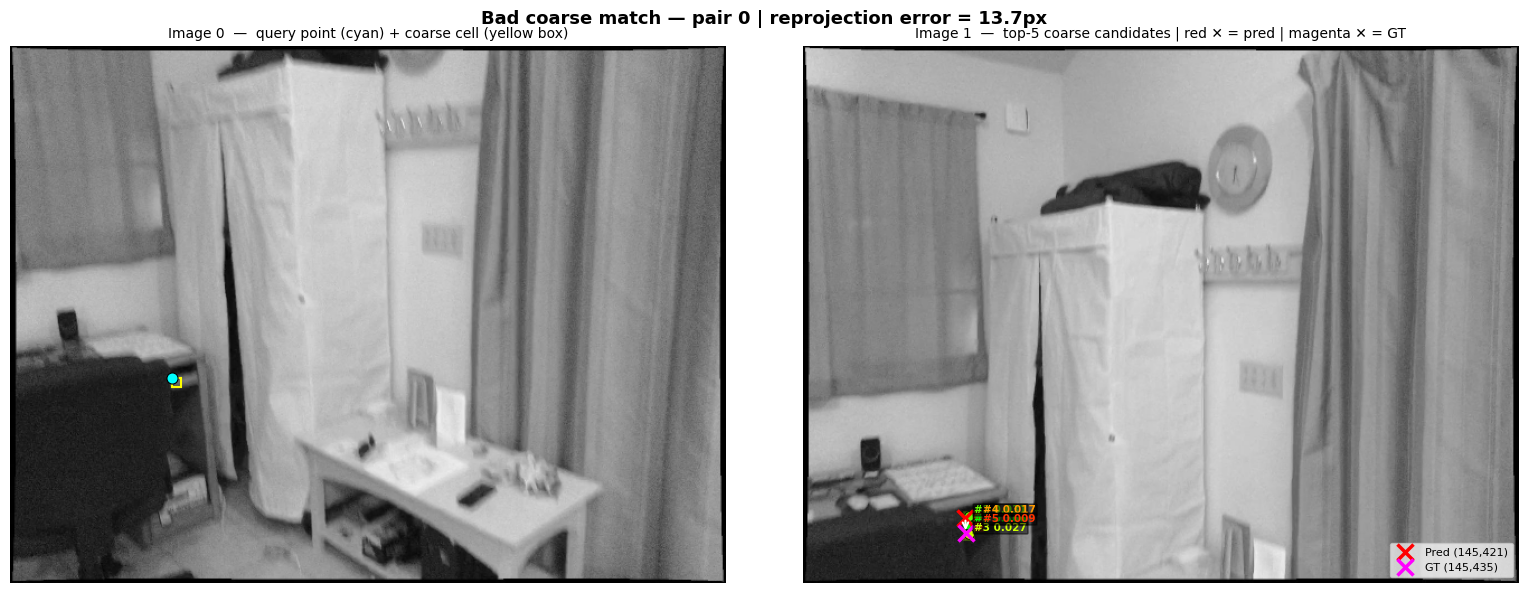

Saved: temp/coarse_bad_match.png


In [8]:
img0 = tensor_to_rgb(found['item']['image0'].unsqueeze(0))
img1 = tensor_to_rgb(found['item']['image1'].unsqueeze(0))

COLORS = ['#00ff00','#66ff00','#ccff00','#ff9900','#ff3300']   # rank 1→5: green to red

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Bad coarse match — pair {found["pair_idx"]} | reprojection error = {err:.1f}px',
    fontsize=13, fontweight='bold'
)

# ── Image 0: query point + its coarse cell ────────────────────────────────────
ax0 = axes[0]
ax0.imshow(img0, cmap='gray')
ax0.set_title('Image 0  —  query point (cyan) + coarse cell (yellow box)', fontsize=10)

# Coarse cell rectangle
cx0 = (int(bad_pt0[0]) // 8) * 8
cy0 = (int(bad_pt0[1]) // 8) * 8
ax0.add_patch(patches.Rectangle((cx0, cy0), 8, 8,
    linewidth=1.5, edgecolor='yellow', facecolor='none'))

# Query point
ax0.plot(*bad_pt0, 'o', color='cyan', markersize=8, markeredgecolor='black', markeredgewidth=0.8)
ax0.axis('off')

# ── Image 1: top-K coarse candidates + predicted + GT ────────────────────────
ax1 = axes[1]
ax1.imshow(img1, cmap='gray')
ax1.set_title('Image 1  —  top-5 coarse candidates | red ✕ = pred | magenta ✕ = GT', fontsize=10)

for rank, (idx, conf) in enumerate(zip(topk_flat, topk_confs)):
    px, py = coarse_idx_to_pixel(idx)
    col = COLORS[rank]
    rx = (idx % W_C) * COARSE_STRIDE
    ry = (idx // W_C) * COARSE_STRIDE
    ax1.add_patch(patches.Rectangle((rx, ry), 8, 8,
        linewidth=2, edgecolor=col, facecolor=col, alpha=0.25))
    ax1.plot(px, py, 'o', color=col, markersize=7,
             markeredgecolor='black', markeredgewidth=0.6)
    ax1.text(px + 5, py - 3, f'#{rank+1} {conf:.3f}',
             color=col, fontsize=7.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))

# Predicted fine match (red X)
ax1.plot(*bad_pt1, 'x', color='red', markersize=12, markeredgewidth=2.5, label=f'Pred ({bad_pt1[0]:.0f},{bad_pt1[1]:.0f})')

# GT location (magenta X)
ax1.plot(*gt_pt1, 'x', color='magenta', markersize=12, markeredgewidth=2.5, label=f'GT ({gt_pt1[0]:.0f},{gt_pt1[1]:.0f})')

# Line from pred to GT
ax1.annotate('', xy=gt_pt1, xytext=bad_pt1,
             arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

ax1.legend(loc='lower right', fontsize=8, framealpha=0.7)
ax1.axis('off')

plt.tight_layout()
plt.savefig('temp/coarse_bad_match.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: temp/coarse_bad_match.png')

## Confidence Heatmap for the Query Point

Show the full confidence distribution of the query coarse cell across all of image1.

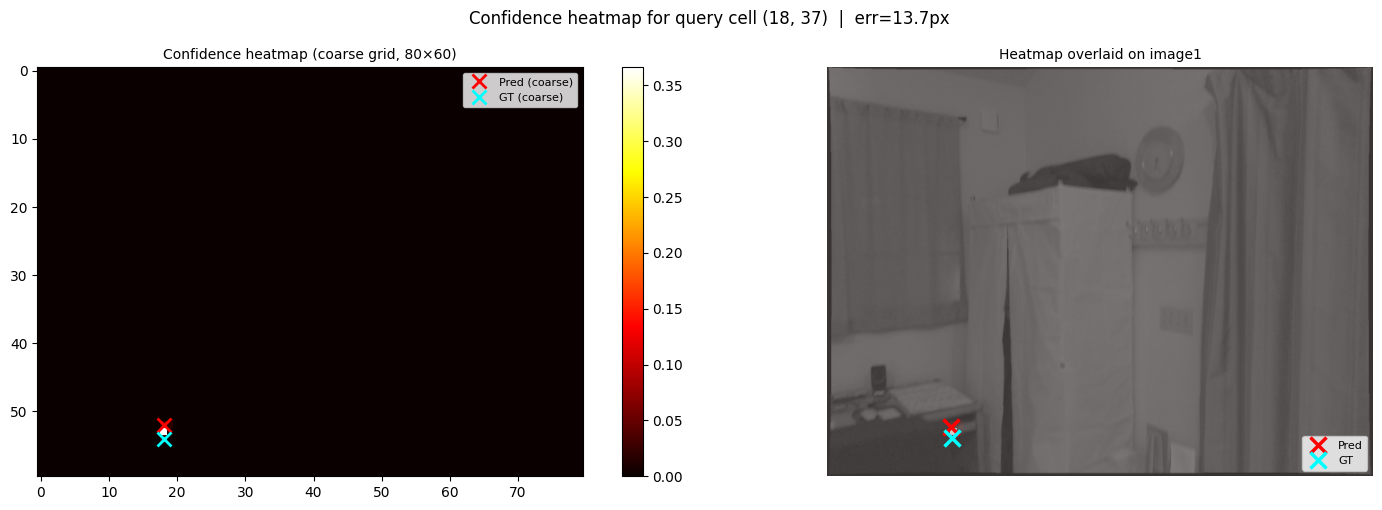

Saved: temp/coarse_heatmap.png


In [9]:
heatmap = conf_row.reshape(H_C, W_C)   # [60, 80]

# GT coarse cell
gt_cx = int(gt_pt1[0]) // COARSE_STRIDE
gt_cy = int(gt_pt1[1]) // COARSE_STRIDE

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Confidence heatmap for query cell ({int(bad_pt0[0])//8}, {int(bad_pt0[1])//8})  |  err={err:.1f}px', fontsize=12)

# Heatmap alone
ax = axes[0]
im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
ax.set_title('Confidence heatmap (coarse grid, 80×60)', fontsize=10)
ax.plot(int(bad_pt1[0])//8, int(bad_pt1[1])//8, 'x', color='red',    markersize=10, markeredgewidth=2, label='Pred (coarse)')
ax.plot(gt_cx,               gt_cy,               'x', color='cyan',   markersize=10, markeredgewidth=2, label='GT (coarse)')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)

# Heatmap overlaid on image1
ax2 = axes[1]
heatmap_up = cv2.resize(heatmap, (TARGET_W, TARGET_H), interpolation=cv2.INTER_NEAREST)
heatmap_norm = (heatmap_up - heatmap_up.min()) / (heatmap_up.max() - heatmap_up.min() + 1e-8)
ax2.imshow(img1, alpha=0.6)
ax2.imshow(heatmap_norm, cmap='hot', alpha=0.5, vmin=0, vmax=1)
ax2.plot(*bad_pt1, 'x', color='red',     markersize=12, markeredgewidth=2.5, label=f'Pred')
ax2.plot(*gt_pt1,  'x', color='cyan',    markersize=12, markeredgewidth=2.5, label=f'GT')
ax2.set_title('Heatmap overlaid on image1', fontsize=10)
ax2.legend(fontsize=8, loc='lower right')
ax2.axis('off')

plt.tight_layout()
plt.savefig('temp/coarse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: temp/coarse_heatmap.png')